In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [4]:
pd.set_option("display.float_format", "{:.2f}".format) # Display float values with 2 decimal places

In [5]:
sns.set(style="whitegrid", palette="Set2", font_scale=1.1) # Set Seaborn style and font scale

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [8]:
df.dropna(inplace=True) # Drop rows with missing values

In [9]:
df.shape

(1332, 10)

In [10]:
df.isna().sum().sum()

np.int64(0)

In [11]:
df.describe(include="all")

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


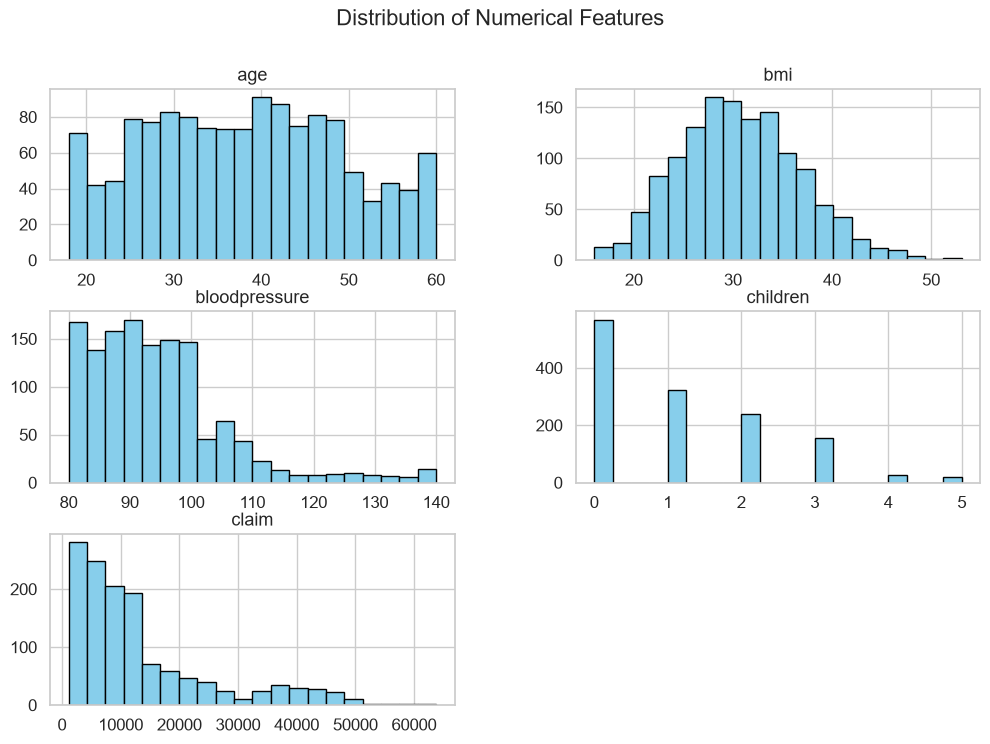

In [12]:
numarical_columns = ["age", "bmi", "bloodpressure", "children", "claim"] 
df[numarical_columns].hist(bins=20, figsize=(12, 8), color="skyblue", edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

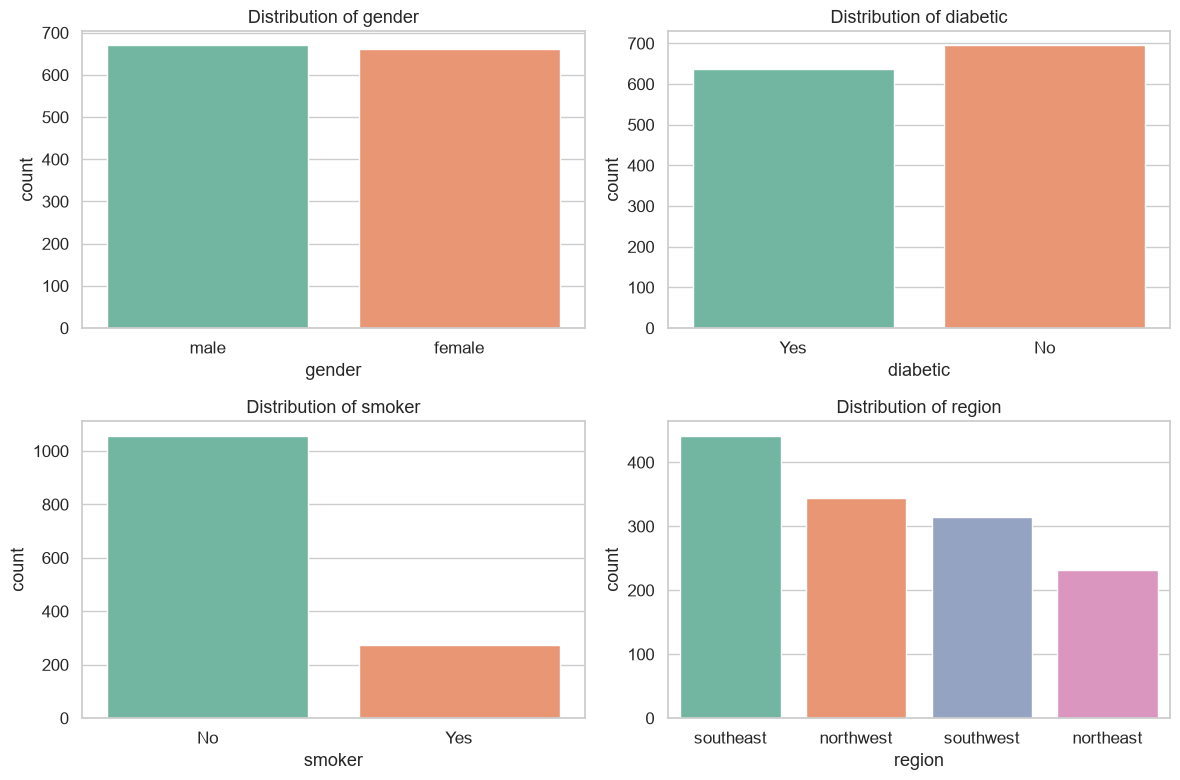

In [13]:
categorical_columns = ["gender", "diabetic", "smoker", "region"]

plt.figure(figsize=(12, 8))

for i, column in enumerate(categorical_columns, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=column, hue=column)
    plt.title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

In [14]:
df.groupby(["gender", "smoker"])["claim"].mean().round(2) # Average claim by gender and smoker status

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

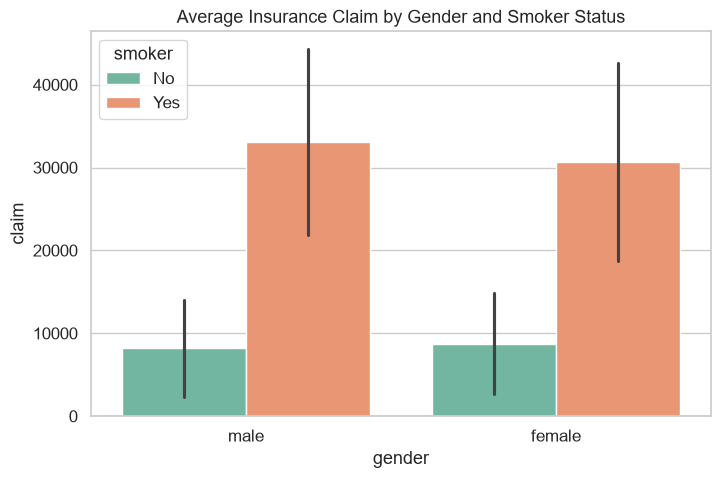

In [15]:
# Visualize the average insurance claim
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="gender", y="claim", hue="smoker", estimator="mean", errorbar="sd")
plt.title("Average Insurance Claim by Gender and Smoker Status")
plt.show()

In [16]:
pivot_region_diabetic = df.groupby(["region", "diabetic"])["claim"].mean().unstack() # Create a pivot table for average claim by region and diabetic status

In [17]:
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


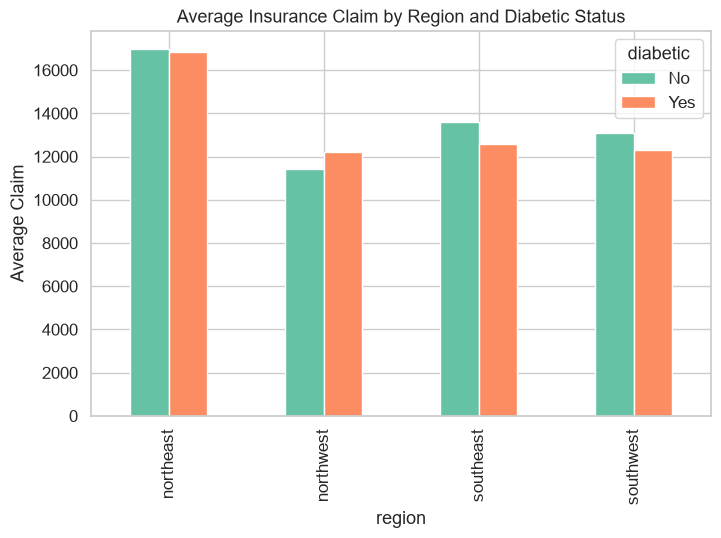

In [18]:
# Visualize the average insurance claim by region and diabetic status
pivot_region_diabetic.plot(kind="bar", figsize=(8, 5))
plt.title("Average Insurance Claim by Region and Diabetic Status")
plt.ylabel("Average Claim")
plt.show()

In [19]:
pivot_table = pd.pivot_table(df, values="claim", index="region", columns="smoker", aggfunc="mean") # Create a pivot table for average claim by region and smoker status
pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [20]:
pivot_table = pd.pivot_table(df, values="claim", index="children", columns="diabetic", aggfunc="mean")
pivot_table

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


In [21]:
df[numarical_columns].corr() # Calculate the correlation matrix for numerical features

,age,bmi,bloodpressure,children,claim
age,1.00,-0.04,-0.06,-0.03,-0.03
bmi,-0.04,1.00,0.14,0.01,0.20
bloodpressure,-0.06,0.14,1.00,-0.03,0.53
children,-0.03,0.01,-0.03,1.00,0.06
claim,-0.03,0.20,0.53,0.06,1.00


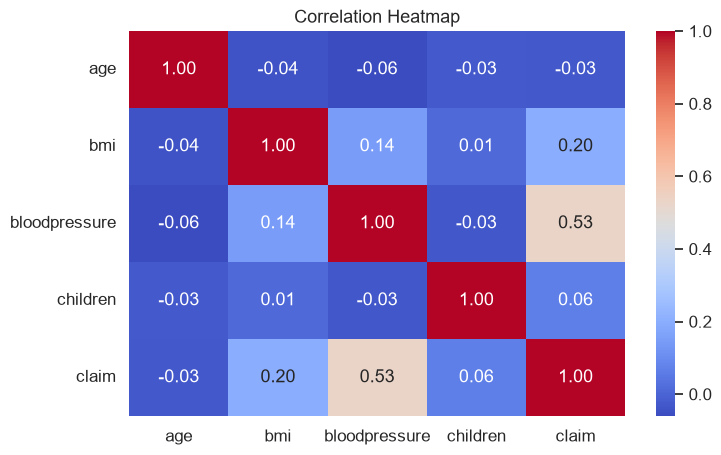

In [22]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[numarical_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

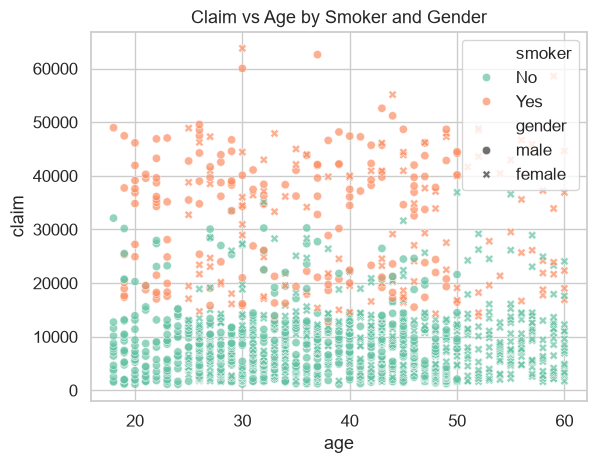

In [23]:
sns.scatterplot(data=df, x="age", y="claim", hue="smoker", style="gender", alpha=0.7) # Create a scatter plot of claim vs age, colored by smoker status and shaped by gender
plt.title("Claim vs Age by Smoker and Gender")
plt.show()

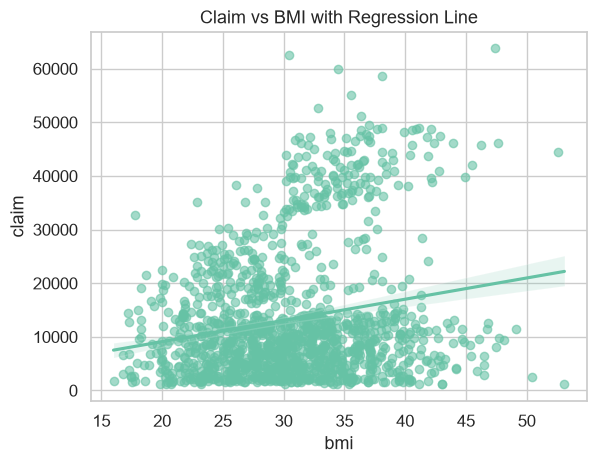

In [24]:
sns.regplot(data=df, x="bmi", y="claim", scatter_kws={"alpha":0.6}) # Create a regression plot of claim vs bmi
plt.title("Claim vs BMI with Regression Line")
plt.show()

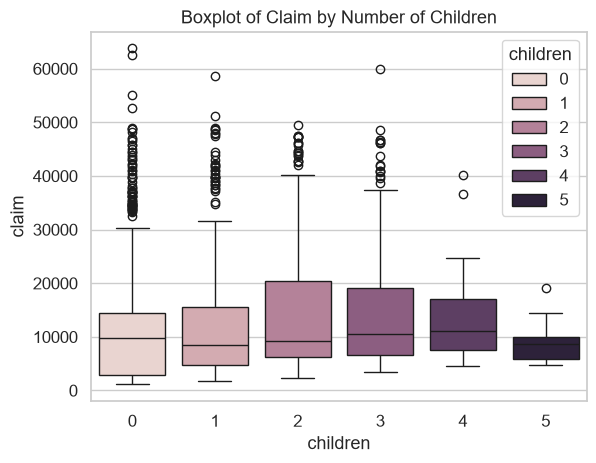

In [25]:
sns.boxplot(data=df, x="children", y="claim", hue="children")
plt.title("Boxplot of Claim by Number of Children")
plt.show()

In [26]:
df["age_group"] = pd.cut(df["age"], bins=[0, 18, 30, 45, 60, 100], labels=["0-18", "19-30", "31-45", "46-60", "60+"]) # Create age groups for analysis

In [27]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,31-45
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,19-30
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,19-30
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,19-30
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,19-30
...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40,31-45
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07,46-60
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40,19-30
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87,31-45


In [28]:
df["age_group"].value_counts()

age_group
31-45    553
46-60    383
19-30    380
0-18      16
60+        0
Name: count, dtype: int64

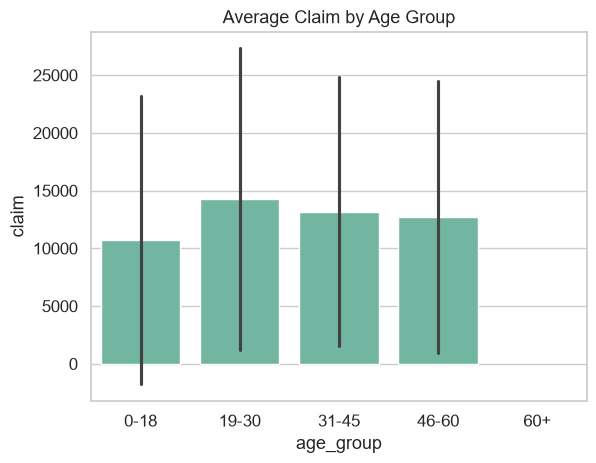

In [29]:
sns.barplot(data=df, x="age_group", y="claim", estimator="mean", errorbar="sd") # Create a bar plot of average claim by age group
plt.title("Average Claim by Age Group")
plt.show()

In [30]:
df["bmi_category"] = pd.cut(df["bmi"], bins=[0, 18.5, 24.9, 29.9, 100], labels=["underwieght", "normal", "overweight", "observe"])

In [31]:
df["bmi_category"].value_counts()

bmi_category
observe        702
overweight     387
normal         222
underwieght     21
Name: count, dtype: int64

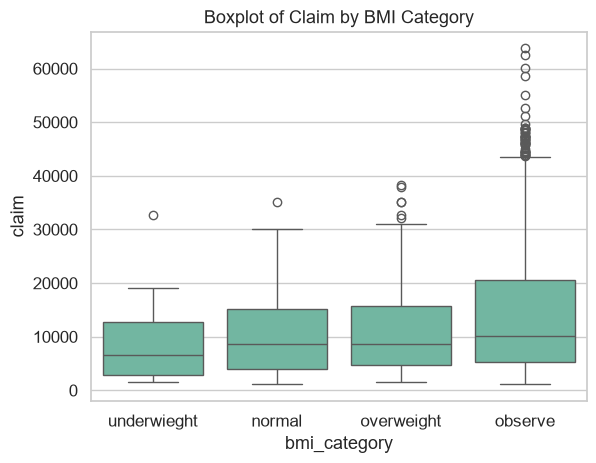

In [32]:
sns.boxplot(data=df, x="bmi_category", y="claim")
plt.title("Boxplot of Claim by BMI Category")
plt.show()

In [39]:
region_stats = df.groupby("region").agg(
    smoker_rate = ("smoker", lambda X: (X == "Yes").mean() * 100), # The percentage of smokers in each region.
    mean_claim = ("claim", "mean") # The average claim amount in each region.
).reset_index()

In [40]:
region_stats

,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


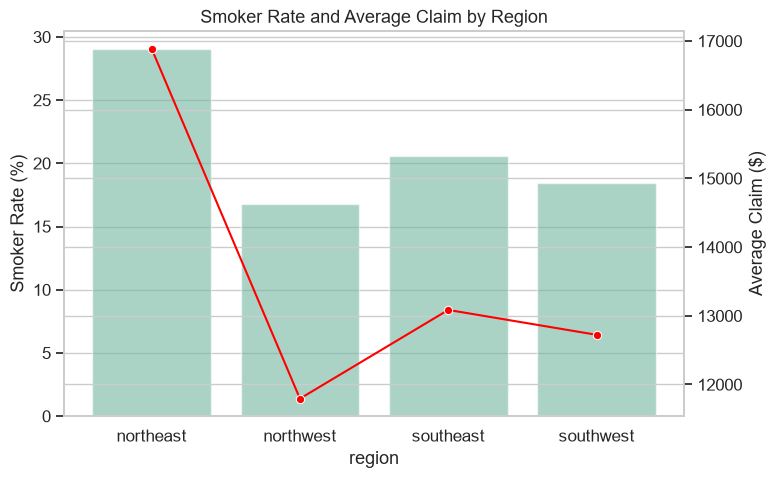

In [42]:
fig, ax1 = plt.subplots(figsize=(8, 5))
sns.barplot(data=region_stats, x="region", y="smoker_rate", ax=ax1, alpha=0.6)
ax2 = ax1.twinx() # Create a second y-axis for the mean claim
sns.lineplot(data=region_stats, x="region", y="mean_claim", ax=ax2, color="red", marker="o")

ax1.set_ylabel("Smoker Rate (%)")
ax2.set_ylabel("Average Claim ($)")
plt.title("Smoker Rate and Average Claim by Region")
plt.show()